##**Aula 2 - Análise Exploratória de Dados (EDA)**

In [1]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

#Análise Exploratória

In [3]:
url_rolling = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/main/Machine-Learning/dataset_rolling_stones.xlsx"
df_rolling = pd.read_excel(url_rolling)
df_rolling.head()


,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106


In [4]:
df_rolling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1610 non-null   object        
 1   album             1610 non-null   object        
 2   release_date      1610 non-null   datetime64[ns]
 3   track_number      1610 non-null   int64         
 4   acousticness      1610 non-null   float64       
 5   danceability      1610 non-null   float64       
 6   energy            1610 non-null   float64       
 7   instrumentalness  1610 non-null   float64       
 8   liveness          1610 non-null   float64       
 9   loudness          1610 non-null   float64       
 10  speechiness       1610 non-null   float64       
 11  tempo             1610 non-null   float64       
 12  valence           1610 non-null   float64       
 13  popularity        1610 non-null   int64         
 14  duration_ms       1610 n

In [5]:
df_rolling.shape

(1610, 15)

In [6]:
#entender oinício e fim dos anos de lançcamento dos álbuns
print("Data inicial:", df_rolling["release_date"].min())
print("Data final:", df_rolling["release_date"].max())

Data inicial: 1964-04-16 00:00:00
Data final: 2022-06-10 00:00:00


In [7]:
df_rolling.isnull().sum() #validar se temos nulos para realizar tratativa

,0
name,0
album,0
release_date,0
track_number,0
acousticness,0
danceability,0
energy,0
instrumentalness,0
liveness,0
loudness,0


In [8]:
df_rolling.duplicated().sum() #analisei que tem 6 casos duplicados, necessário aprofundar para entender se precisamos realizar tratativas

np.int64(6)

In [9]:
df_rolling[df_rolling.duplicated()] #o que esta duplicado é o nome do album, não é necessário tratativa

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
928,Some Girls - Remastered,Some Girls (Deluxe Version),1978-06-09,4,0.5270,0.474,0.938,0.520000,0.299,-2643.0,0.0898,71995.00,0.505,21,276933
929,Lies - Remastered,Some Girls (Deluxe Version),1978-06-09,5,0.4370,0.382,0.997,0.950000,0.617,-1568.0,0.1880,162428.00,0.563,16,191266
935,Claudine,Some Girls (Deluxe Version),1978-06-09,1,0.0144,0.439,0.977,0.022100,0.383,-4386.0,0.1280,105124.00,0.364,17,222253
939,No Spare Parts,Some Girls (Deluxe Version),1978-06-09,5,0.2400,0.594,0.762,0.000015,0.712,-5145.0,0.0292,72648.00,0.540,19,270466
940,Don't Be A Stranger,Some Girls (Deluxe Version),1978-06-09,6,0.0610,0.720,0.867,0.029700,0.385,-5871.0,0.0390,127329.00,0.847,15,246266
946,Petrol Blues,Some Girls (Deluxe Version),1978-06-09,12,0.7690,0.835,0.621,0.114000,0.116,-8007.0,0.0406,115.87,0.336,13,95626


In [10]:
df_rolling.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161536,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920


In [11]:
#se observar a duração esta em ms, ideal alterar para min
df_rolling["duration_em_min"] = df_rolling["duration_ms"]/60000
df_rolling = df_rolling.drop(["duration_ms"],axis=1)
df_rolling.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_em_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,0.810667
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,4.219550
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,4.386000
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,5.098000
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,5.085100


In [12]:
df_rolling.groupby("album")[["duration_em_min","tempo"]].mean()

,duration_em_min,tempo
album,,
12 X 5,2.682068,139795.570000
12 x 5,2.682772,113867.720833
A Bigger Bang (2009 Re-Mastered),4.016356,95953.646875
A Bigger Bang (Live),5.176630,123649.579091
Aftermath,3.899185,125360.000000
...,...,...
Undercover,4.492750,121139.300000
Undercover (2009 Re-Mastered),4.497595,114577.584000
Voodoo Lounge (Remastered 2009),4.118779,110166.243333


In [13]:
df_maior_duracao = df_rolling.groupby("album")["duration_em_min"].mean().sort_values(ascending=False)
df_maior_duracao.head(10)

,duration_em_min
album,
Havana Moon (Live),6.632819
Bridges To Bremen (Live),6.332265
Jamming With Edward,6.042794
Live At The Checkerboard Lounge,6.009647
Totally Stripped - Paris (Live),5.947430
Bridges To Buenos Aires (Live),5.722842
Totally Stripped (Live),5.635596
Licked Live In NYC,5.611830
Steel Wheels Live,5.598142


#Bibliotecas Gráficas

In [14]:
import matplotlib.pyplot as plt


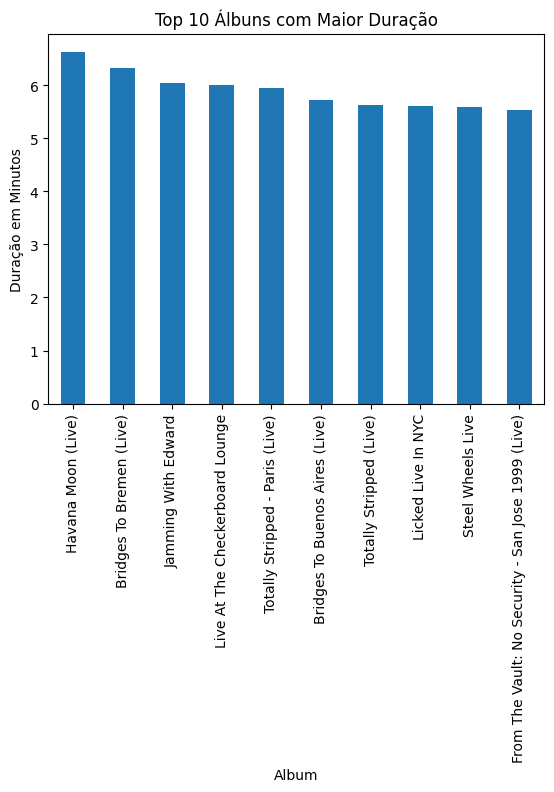

In [15]:
df_maior_duracao.head(10).plot(kind="bar")
plt.xlabel('Album')
plt.ylabel('Duração em Minutos')
plt.title('Top 10 Álbuns com Maior Duração')
plt.show()

In [16]:
top_albuns = df_rolling['album'].value_counts().head(5)
top_albuns

,count
album,
Voodoo Lounge Uncut (Live),56
Honk (Deluxe),47
Tattoo You (Super Deluxe),46
Live Licks,46
Some Girls (Deluxe Version),44


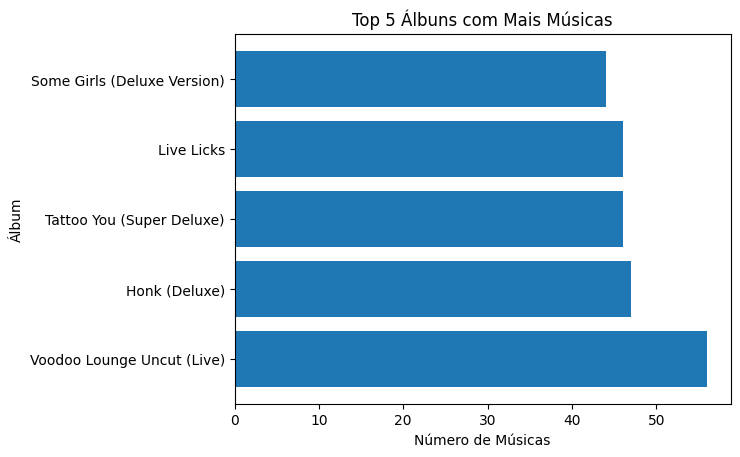

In [17]:
plt.barh(top_albuns.index,top_albuns.values)
plt.title("Top 5 Álbuns com Mais Músicas")
plt.xlabel("Número de Músicas")
plt.ylabel("Álbum")
plt.show()

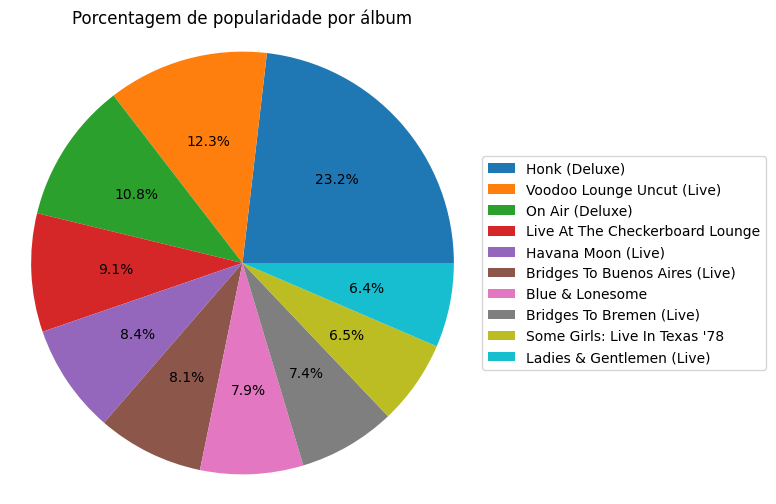

In [18]:
df_ultima_decada = df_rolling[df_rolling['release_date'].between(pd.to_datetime('2011'),pd.to_datetime('2020'))] #no between ele inclui também as datas que coloquei, além das que estão entre
df_por_album = df_ultima_decada.groupby('album')['popularity'].sum().sort_values(ascending=False).head(10)
total_popularity = df_por_album.sum()
df_porcentagem = (df_por_album/total_popularity)*100
labels = df_porcentagem.index.tolist()
sizes = df_porcentagem.values.tolist()
figura,grafico = plt.subplots(figsize=(6,6))
grafico.pie(sizes,autopct="%.1f%%")
grafico.axis("equal") #deixa circular, não oval
plt.title("Porcentagem de popularidade por álbum")
plt.legend(labels,loc="center left",bbox_to_anchor=(1,0.5)) #x = 1 ->fora do gráfico, à direita
plt.show()

In [19]:
! pip install seaborn
import seaborn as sns

#Outliers

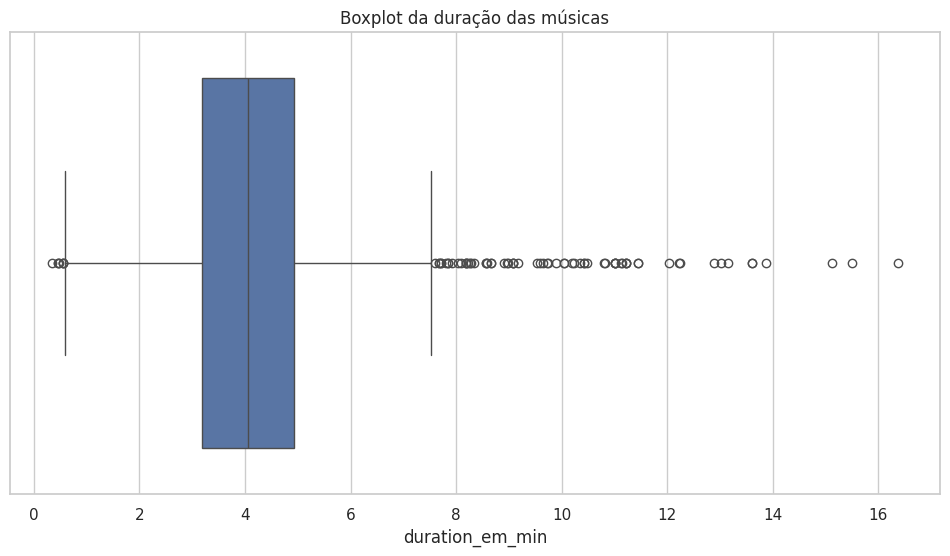

In [20]:
sns.set(style="whitegrid")
fig,axes = plt.subplots(figsize=(12,6))
sns.boxplot(x="duration_em_min",data=df_rolling)
axes.set_title("Boxplot da duração das músicas")
plt.show()

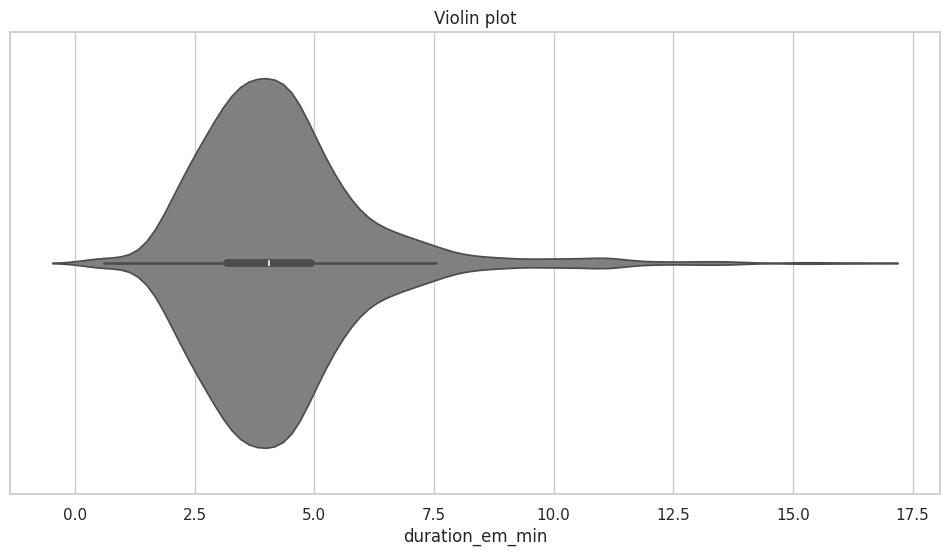

In [21]:
fig,axes = plt.subplots(figsize=(12,6))
sns.violinplot(x="duration_em_min",data=df_rolling,color="gray")
axes.set_title("Violin plot")
plt.show()

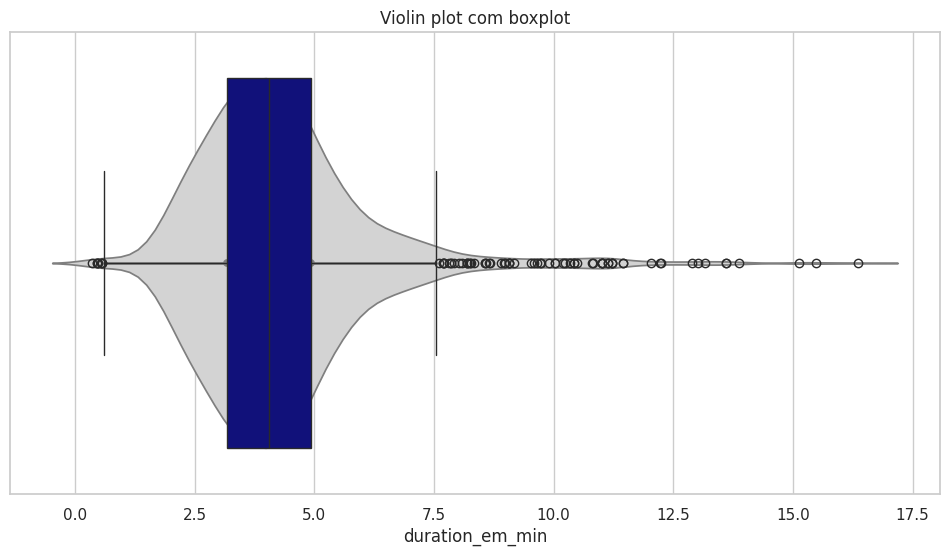

In [22]:
fis,ax = plt.subplots(figsize=(12,6))
sns.violinplot(x="duration_em_min",data=df_rolling,color="lightgray",ax=ax)
sns.boxplot(x="duration_em_min",data=df_rolling,color="darkblue",ax=ax,whis=1.5)
ax.set_title("Violin plot com boxplot")
plt.show()

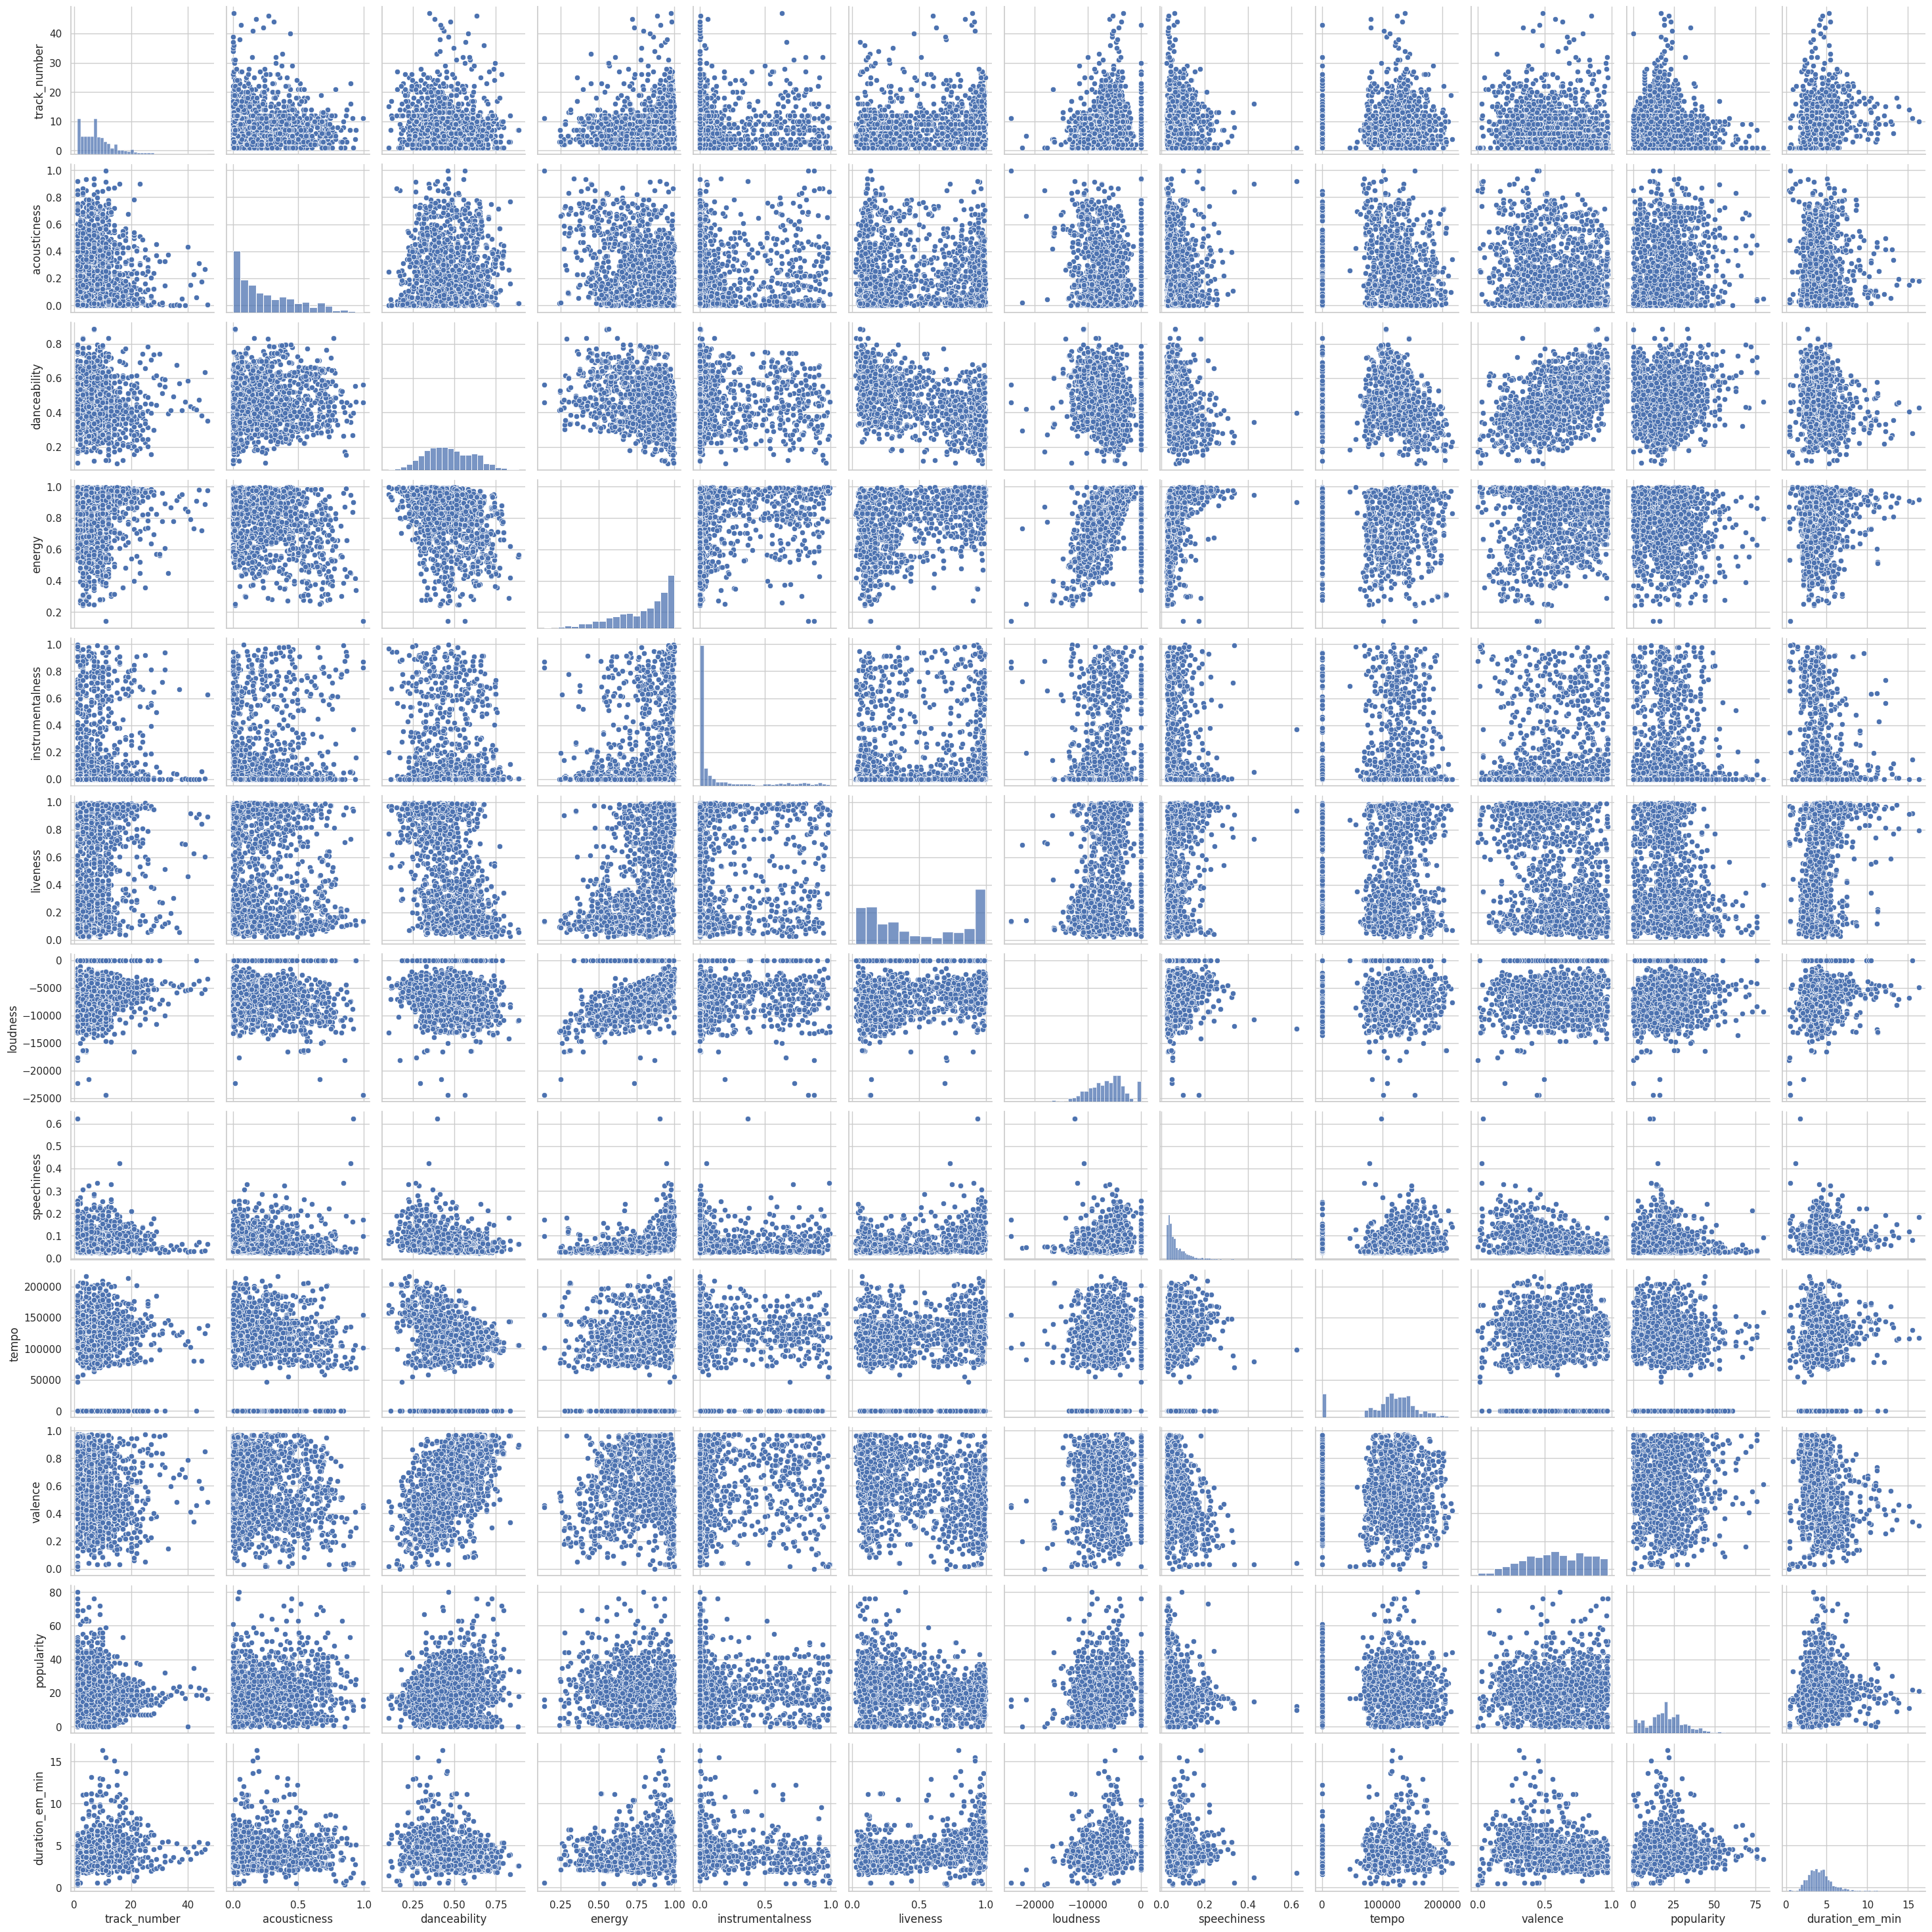

In [23]:
#útil para ver cada um dos parâmetros relacionados
sns.pairplot(df_rolling)
plt.show()

In [24]:
def classifica_musica_ao_vivo(df_rolling):
  if df_rolling["liveness"] >= 0.8:
    return True
  else:
    return False

In [25]:
df_rolling["ao_vivo"] = df_rolling.apply(classifica_musica_ao_vivo,axis=1)
df_rolling.groupby("ao_vivo")["ao_vivo"].count()

,ao_vivo
ao_vivo,
False,1112
True,498


In [26]:
df_gravado_em_estudio = df_rolling[df_rolling["ao_vivo"]== False]
df_ao_vivo = df_rolling[df_rolling["ao_vivo"]== True]

In [27]:
print("Média das músicas ao vivo é: ", df_ao_vivo["duration_em_min"].mean())
print("Média das músicas gravadas em estúdio é: ", df_gravado_em_estudio["duration_em_min"].mean())

Média das músicas ao vivo é:  5.088648962516734
Média das músicas gravadas em estúdio é:  3.940451363908873


#Histograma e Teste de Normalidade

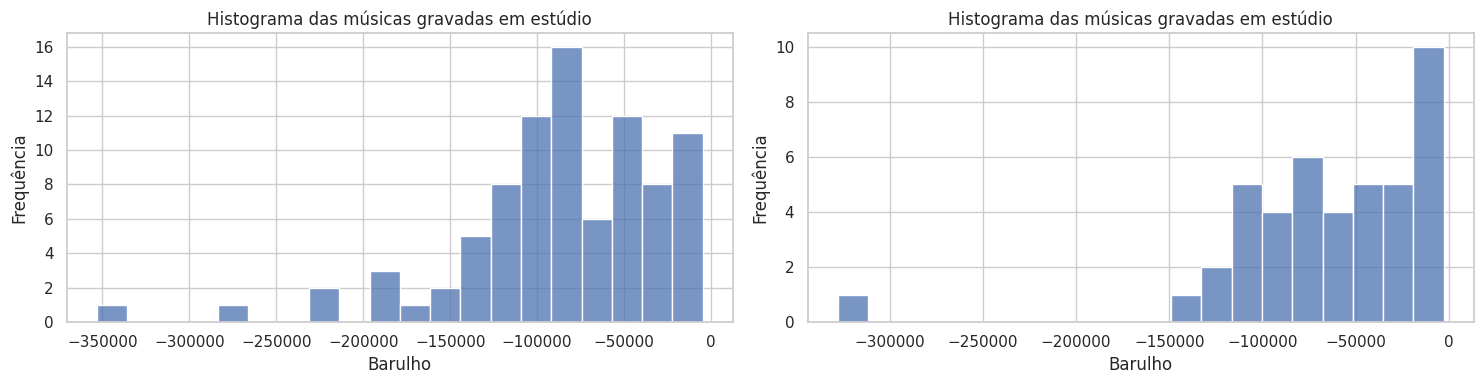

In [28]:
df_studio = df_gravado_em_estudio.groupby("album")["loudness"].sum()
df_ao_vivo = df_ao_vivo.groupby("album")["loudness"].sum()

fig,axes = plt.subplots(1,2, figsize=(15,4)) #usado o 1,2 para definir que é uma linha e duas colunas, para termos os dois gráficos
sns.histplot(data=df_studio,bins=20,ax=axes[0]) #ax=axes[0 gráfico da esquerda
axes[0].set_title("Histograma das músicas gravadas em estúdio")
axes[0].set_xlabel("Barulho")
axes[0].set_ylabel("Frequência")

sns.histplot(data=df_ao_vivo,bins=20,ax=axes[1])
axes[1].set_title("Histograma das músicas gravadas em estúdio")
axes[1].set_xlabel("Barulho")
axes[1].set_ylabel("Frequência")

fig.tight_layout()
plt.show()


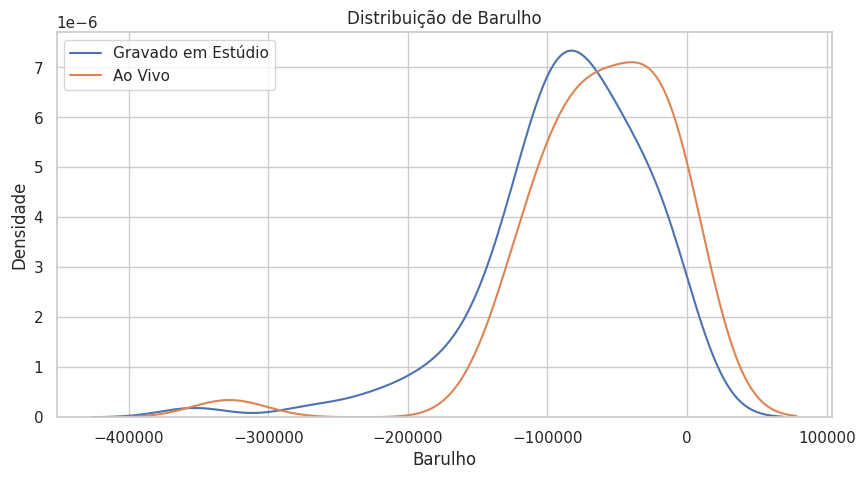

In [29]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df_studio,label="Gravado em Estúdio")
sns.kdeplot(data=df_ao_vivo,label="Ao Vivo")
plt.title("Distribuição de Barulho")
plt.xlabel("Barulho")
plt.ylabel("Densidade")
plt.legend()
plt.show()

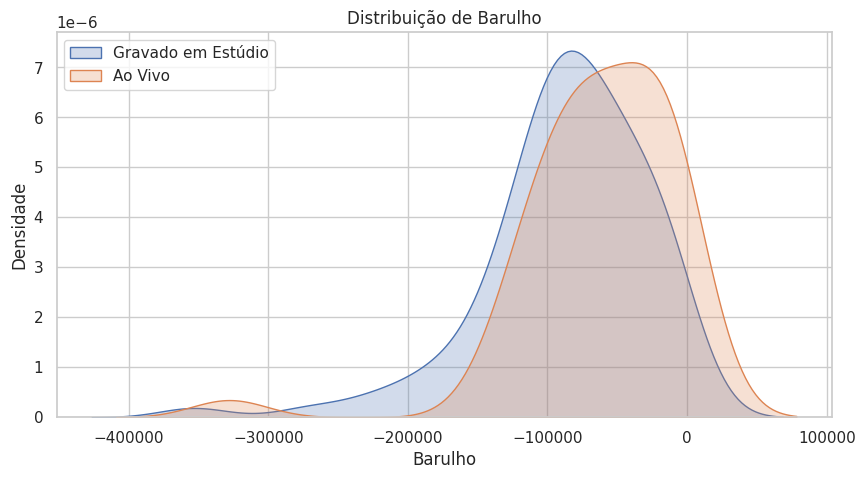

In [30]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df_studio,label="Gravado em Estúdio",fill="True")
sns.kdeplot(data=df_ao_vivo,label="Ao Vivo",fill="True")
plt.title("Distribuição de Barulho")
plt.xlabel("Barulho")
plt.ylabel("Densidade")
plt.legend()
plt.show()

Quando colocamos ambos gráficos juntos, podemos visualizarmos de forma clara os picos de frequência dos valores e a diferença entre os albuns gravados em studio e ao-vivo.

In [31]:
! pip install scipy

In [32]:
from scipy.stats import shapiro

O teste de Shapiro-Wilk é um teste de hipótese que verifica se uma amostra de dados segue uma distribuição normal. A hipótese nula do teste é que a amostra segue uma distribuição normal. Se o valor-p (valor de probabilidade) do teste for menor do que o nível de significância escolhido (geralmente 0,05), a hipótese nula é rejeitada e conclui-se que a amostra não segue uma distribuição normal.

É importante lembrar que apesar que tais testes são úteis para verificarmos nossa amostra segue uma distribuição normal, eles possuem suas limitações e devem ser usados de forma cautelosa sempre respeitando seus teoremas, é importante verificarmos visualmente a distribuição/densidade dos dados e considerar o contexto tambem.

In [33]:
stat, p = shapiro(df_studio)
print("Soma do barulho dos álbuns de estúdio: ")
print("Estatística de teste: {:.4f},valor p: {}".format(stat,p))

if p > 0.05:
  print("Não há evidência suficiente para rejeitar a hipótese de normalidade.")
else:
  print("Há evidência suficiente para rejeitar a hipótese de normalidade.")

Soma do barulho dos álbuns de estúdio: 
Estatística de teste: 0.8958,valor p: 3.2961810837731026e-06
Há evidência suficiente para rejeitar a hipótese de normalidade.


In [34]:
stat, p = shapiro(df_ao_vivo)
print("Soma do barulho dos álbuns ao vivo: ")
print("Estatística de teste: {:.4f},valor p: {}".format(stat,p))

if p > 0.05:
  print("Não há evidência suficiente para rejeitar a hipótese de normalidade.")
else:
  print("Há evidência suficiente para rejeitar a hipótese de normalidade.")

Soma do barulho dos álbuns ao vivo: 
Estatística de teste: 0.7913,valor p: 2.3506009149709294e-06
Há evidência suficiente para rejeitar a hipótese de normalidade.


In [35]:
from scipy.stats import mannwhitneyu

O teste de Mann-Whitney U é um teste estatístico que compara duas amostras para determinar se elas têm distribuições diferentes. Ele classifica as observações de cada amostra(ou seja ordená-las em uma determinada ordem com base nos valores que representam), soma as classificações em cada amostra e compara as somas para obter um valor U. Se esse valor for grande o suficiente, podemos concluir que as médias das duas amostras são significativamente diferentes. Em resumo, o teste de Mann-Whitney U é usado para verificar se duas amostras são estatisticamente diferentes entre si, mesmo que elas não sigam uma distribuição normal.

In [36]:
#Realizando teste de mann withney U
#Aqui precisamos trazer os nossos dois dataframes na seguinte ordem H0 e depois  O H1
#Ou seja estamos dizendo que o df_studio é diferente do df_ao_vivo
#Não se esqueça de trazer amostras aleatórias usando o método sample do pandas.
stat, p = mannwhitneyu(df_studio.sample(len(df_studio)), df_ao_vivo.sample(len(df_ao_vivo)),  alternative='less')

#Imprimindo os resultados do teste
print('Estatística de teste U: ', stat)
print('Valor p: ', p)

#Verifica se a diferença nas médias é estatisticamente significante
alpha = 0.05
if p < alpha:
    print('Diferença estatisticamente significante')
else:
    print('Não há diferença estatisticamente significante')


Estatística de teste U:  1367.0
Valor p:  0.0050727361177996585
Diferença estatisticamente significante


####Correlação
Quando falamos sobre correlação, queremos entender o grau de associação entre duas variaveís, para assim entender a relação da nossa variável target entre as outras. Importante ressaltar, que correlação não significa causalidade, ou seja, não podemos afirmar que uma variável é a causa/motivo da outra que possui uma alta relação.

In [37]:
media_por_album = df_rolling.groupby("album")["valence"].mean().reset_index()
media_por_album = media_por_album.rename(columns={"valence":"media_valence"})
media_por_album.head()

,album,media_valence
0,12 X 5,0.704000
1,12 x 5,0.689917
2,A Bigger Bang (2009 Re-Mastered),0.602750
3,A Bigger Bang (Live),0.253482
4,Aftermath,0.684818


In [38]:
media_por_album["sentimento"]= ["positivo" if v > 0.6 else "negativo" for v in media_por_album["media_valence"]]
media_por_album.groupby("sentimento")["sentimento"].count()

,sentimento
sentimento,
negativo,38
positivo,52


In [39]:
df_resultado_final = pd.merge(df_rolling,media_por_album,on="album")
df_resultado_final.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_em_min,ao_vivo,media_valence,sentimento
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,0.810667,True,0.27117,negativo
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,4.219550,True,0.27117,negativo
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,4.386000,True,0.27117,negativo
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,5.098000,True,0.27117,negativo
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,5.085100,True,0.27117,negativo


In [40]:
#Cria a matriz de correlação
matriz_correlacao = df_resultado_final.select_dtypes(include=["number"]).corr()
#Seleciona apenas a linha e a coluna correspondentes à coluna "media_valence"
correlacao_sentimento = matriz_correlacao['media_valence']
#Vamos verificar a relação entre as outras colunas a média valence dos albuns, onde classificamos se ela é positivo ou negativo
display(correlacao_sentimento)

,media_valence
track_number,-0.115007
acousticness,0.015491
danceability,0.492945
energy,-0.347447
instrumentalness,0.133741
liveness,-0.571749
loudness,-0.229543
speechiness,-0.416005
tempo,-0.028887
valence,0.603258


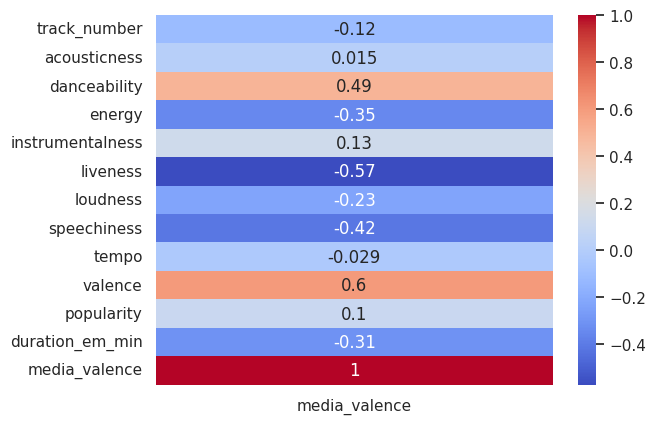

In [41]:
sns.heatmap(correlacao_sentimento.to_frame(),annot=True,cmap="coolwarm") #annot=true é para escrever o numero dentro
plt.show()


uma alta correlação entre duas variáveis indica que elas estão fortemente relacionadas e tendem a se mover juntas na mesma direção, seja aumentando ou diminuindo. Quando a correlação é positiva, as variáveis tendem a aumentar ou diminuir juntas, enquanto que quando a correlação é negativa, uma variável tende a aumentar enquanto a outra tende a diminuir. Ou seja podemos entender que a coluna Valence e danceability estão fortemente relacionada a nossa coluna alvo de análise, a media_valence, mas como a valence tem o mesmo significado e estamos apenas considerando a média dele, devemos somente considerar o danceability.

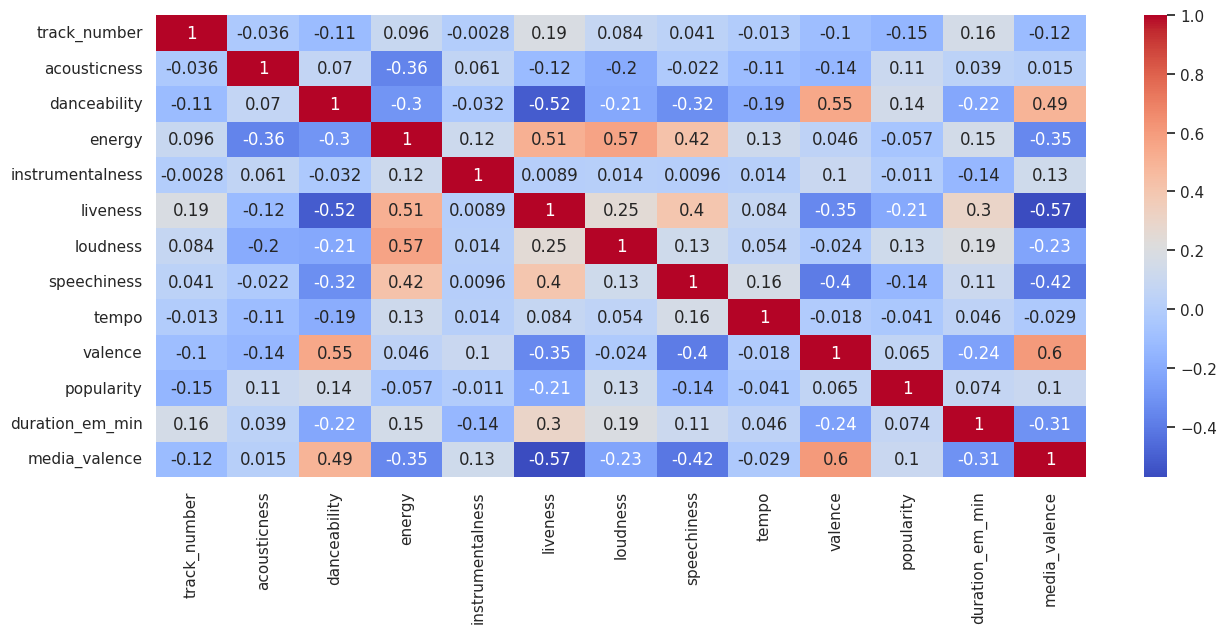

In [42]:
plt.figure(figsize=(15,6))
num_cols = df_resultado_final.select_dtypes(include=["number"])
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.show()

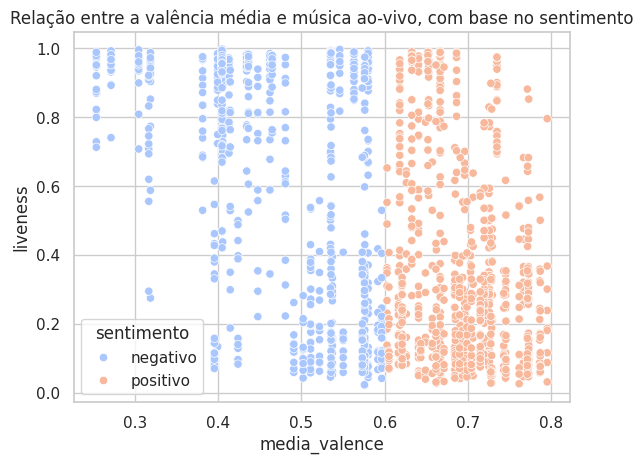

In [43]:
#Vamos agora verificar uma coluna que não está fortemente correlacionada
sns.scatterplot(x='media_valence', y='liveness', hue='sentimento', data=df_resultado_final, palette='coolwarm')
plt.xlabel('media_valence')
plt.ylabel('liveness')
plt.title('Relação entre a valência média e música ao-vivo, com base no sentimento')
plt.show()

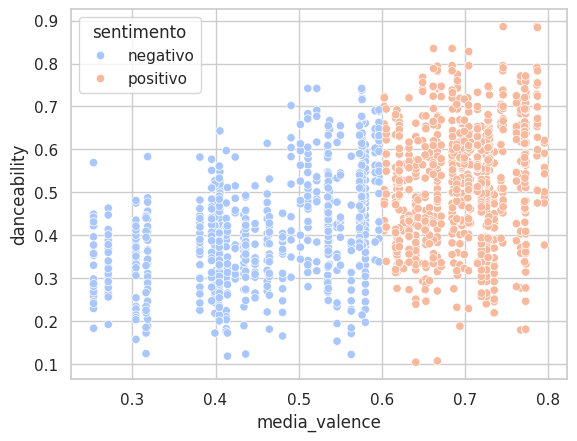

In [44]:
sns.scatterplot(x="media_valence", y="danceability", hue="sentimento", data=df_resultado_final, palette = "coolwarm")
plt.xlabel = "Média Valence"
plt.ylabel = "Danceability"
plt.title = "Relação entra a Valência Média e capacidade de Dança das músicas"
plt.show()